## 각 pdb에서 상위 10위 추출

In [ ]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/benchmark'
h3_rmsd_by_pdb = {}
top_10_rmsd_by_pdb = {}
top_rank = 25

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  


for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    sorted_rmsd = sorted(rmsd_list, reverse=False)  # 내림차순 정렬
    top_10_rmsd_by_pdb[pdb] = sorted_rmsd[top_rank-1]  # 상위 10개 선택

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_10_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

### confidence metric과 h3 rmsd 간의 correlation 

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# 1️⃣ CSV load + 전처리
# ============================================================
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/6wgl_insert/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'
base_dir = os.path.dirname(os.path.dirname(csv_file))

df = pd.read_csv(csv_file)
df['h_avg'] = df[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)
best_rows = df.loc[df.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['pure_mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numbers(x):
    if x == pdb_id:
        return []
    return [int(p[1:]) for p in x.split('_') if p.startswith('A')]

best_rows['num_list'] = best_rows['pure_mt_id'].apply(extract_numbers)
best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: sum(25 <= n <= 32 for n in x))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: sum(51 <= n <= 57 for n in x))

# ============================================================
# 2️⃣ RMSD 벡터화 함수
# ============================================================
def load_rmsd_vector(rmsd_path, residue_range=None):
    with open(rmsd_path, 'r') as f:
        rmsd_info = json.load(f)
    if residue_range is None:
        residue_range = sorted(map(int, rmsd_info.keys()))
    vec = np.array([rmsd_info.get(str(r), np.nan) for r in residue_range], dtype=float)
    return vec

# ============================================================
# 3️⃣ 그룹별 처리 함수 (t-SNE 버전)
# ============================================================
def process_group(group_tuple):
    (h1c, h2c), group = group_tuple
    rmsd_vectors = []
    valid_indices = []
    residue_range = None

    for idx, row in group.iterrows():
        # rmsd 경로 지정
        if row['mt_id'] == '6wgl_A_B_C':
            rmsd_path = os.path.join(base_dir, row['mt_id'], row['sample_id'], "rmsd_info.json")
        else:
            rmsd_path = os.path.join(base_dir, row['mt_id'] + '.pkl', row['sample_id'], "_rmsd.json")

        if not os.path.exists(rmsd_path):
            continue
        vec = load_rmsd_vector(rmsd_path)
        if residue_range is None:
            residue_range = sorted(range(len(vec)))
        rmsd_vectors.append(vec)
        valid_indices.append(idx)

    if len(rmsd_vectors) < 2:
        return None

    X = np.vstack(rmsd_vectors)
    
    # 차원 축소 (t-SNE)
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(X)-1))
    X_emb = tsne.fit_transform(X)
    
    # 클러스터링
    n_clusters = min(5, len(X))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_emb)

    result_group = group.loc[valid_indices].copy()
    result_group['cluster_id'] = labels
    return result_group

# ============================================================
# 4️⃣ 멀티프로세싱
# ============================================================
cluster_results = []

with ProcessPoolExecutor(max_workers=36) as executor:
    futures = [executor.submit(process_group, g) for g in best_rows.groupby(['h1_count', 'h2_count'])]
    for fut in as_completed(futures):
        res = fut.result()
        if res is not None:
            cluster_results.append(res)

# 최종 CSV 저장
if cluster_results:
    final_df = pd.concat(cluster_results, ignore_index=True)
    out_csv = os.path.join(base_dir, 'plddt', 'clustered_results.csv')
    final_df.to_csv(out_csv, index=False)
    print("Clustered CSV saved to:", out_csv)
else:
    print("No clustering results")


## 각 pdb에서 confidence 기반 Top N 뽑기 

In [ ]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 
from Bio.PDB import PDBParser

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_path, start_residue=95, end_residue=102):

    parser = PDBParser(QUIET=True)


    structure = parser.get_structure("structure", pdb_path)
    
    # 첫 번째 체인 추출
    first_chain = next(iter(structure[0].get_chains()))
    b_factors = []
    for residue in first_chain:
        residue_id = residue.get_id()
        if residue_id[0] == " ":  # 표준 아미노산만 고려
            residue_number = residue_id[1]
            if start_residue <= residue_number <= end_residue:
                for atom in residue:
                    b_factors.append(atom.get_bfactor())
            
    b_factors_avg = np.mean(b_factors)

    return b_factors_avg

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence/2025-12-09_16-50-34/epoch=27-step=40124/benchmark'
h3_rmsd_by_pdb = {}
b_factors_by_pdb = {}
top_n_rmsd_by_pdb = {}
top_rank = 1

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀
    print(pdb_id)
    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    h3_b_factors = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        plddt_info = os.path.join(sub_dir, sample, "plddts.json")
        with open(cdr_info, 'r') as f:
            rmsd_data = json.load(f)
        with open(plddt_info, 'r') as f:
            plddt_data = json.load(f)
        h3_cdrs.append(rmsd_data['h3_rms'])
        h3_b_factors.append(plddt_data['h3_aa'])

    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  
    b_factors_by_pdb[pdb_key] = h3_b_factors

for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    b_factors = b_factors_by_pdb[pdb]
    top_n_b_factor = sorted(b_factors, reverse=True)[top_rank-1]
    top_n_index = b_factors.index(top_n_b_factor)
    top_n_rmsd_by_pdb[pdb] = rmsd_list[top_n_index] 

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_n_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

### 각 모델 별 rmsd 비교 

In [ ]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/benchmark',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

# PDB ID 수집
all_pdb_ids = set()

for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue  # 설정 파일은 건너뜀

        pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
        all_pdb_ids.add(pdb_key)

        # 현재 프로젝트에서 RMSD 값 불러오기
        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            if 'sample' not in sample:
                continue
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            with open(cdr_info, 'r') as f:
                data = json.load(f)
            h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
sorted_pdb_ids = df_sorted["pdb_name"].tolist()
sorted_pdb_ids = [filename.split('_')[0] for filename in sorted_pdb_ids if filename.split('_')[0] in all_pdb_ids]

# PDB ID를 3등분
num_splits = 2
split_size = len(sorted_pdb_ids) // num_splits
split_pdb_ids = [sorted_pdb_ids[i * split_size:(i + 1) * split_size] for i in range(num_splits - 1)]
split_pdb_ids.append(sorted_pdb_ids[(num_splits - 1) * split_size:])  # 마지막 부분 추가

# 색상 설정
colors = ['blue', 'orange']
handles = [
    mpatches.Patch(
        color=colors[idx],
        label=dir.split('/')[5] if len(dir.split('/')) > 5 else dir.split('/')[3]
    )
    for idx, dir in enumerate(pred_dirs)
]

# 📌 그래프 그리기 (3개로 분할)
# 📌 그래프 그리기 (2개로 분할)
for i, pdb_subset in enumerate(split_pdb_ids):
    plt.figure(figsize=(12, 6))

    tenth_values = {pred_dirs[0]: [], pred_dirs[1]: []}

    for idx, pred_dir in enumerate(pred_dirs):
        h3_rmsd_sorted = [h3_rmsd_by_pdb[pred_dir].get(pdb, []) for pdb in pdb_subset]

        # 박스플롯 그리기
        boxplot = plt.boxplot(h3_rmsd_sorted, positions=np.arange(len(pdb_subset)) + (idx * 0.2), widths=0.2,
                              patch_artist=True, boxprops=dict(facecolor=colors[idx], alpha=0.5),
                              medianprops=dict(color='black'))

        # 각 PDB에 대해 낮은 것부터 10번째 값을 저장
        for rmsd_list in h3_rmsd_sorted:
            sorted_rmsd = sorted(rmsd_list)
            if len(sorted_rmsd) >= 10:
                tenth_value = sorted_rmsd[9]  # 인덱스는 0부터 시작하므로 10번째 값은 인덱스 9
            else:
                tenth_value = None  # 또는 np.nan
            tenth_values[pred_dir].append(tenth_value)

    # 중앙값 비교 후 색상 결정
    xlabel_colors = []
    for j, pdb in enumerate(pdb_subset):
        if tenth_values[pred_dirs[0]][j] < tenth_values[pred_dirs[1]][j]:
            xlabel_colors.append(colors[0])  # 첫 번째 모델 색상
        else:
            xlabel_colors.append(colors[1])  # 두 번째 모델 색상

    # 📌 PDB ID의 색상 
    plt.xticks(range(len(pdb_subset)), pdb_subset, rotation=90)  # color 제거

    # 📌 x축 레이블 개별적으로 색상 설정
    ax = plt.gca()  # 현재 축 가져오기
    for label, color in zip(ax.get_xticklabels(), xlabel_colors):
        label.set_color(color)


    # 그래프 설정
    plt.xlabel("PDB ID")
    plt.ylabel("H3 CDR RMSD")
    plt.title(f"H3 CDR RMSD by PDB ID (Part {i+1})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(handles=handles)

    # 그래프 표시
    plt.show()



# check self-confidence correlation 

## by sample 

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_dir, cdr_type):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    start_residue = cdr_chothia[cdr_type][0]
    end_residue = cdr_chothia[cdr_type][1]
    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in sorted(os.listdir(pdb_dir)):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    # 각 원자의 B-factor 가져오기
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())

        b_factors_avg.append(np.mean(b_factors))
        
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
cdr_type = "h1"
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-10-29_12-41-30/7u8g_D_E_A'
pdb_id = pdb_dir.split('/')[-1]
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir, cdr_type=cdr_type)

# RMSD 값 수집

cdr_rmsd_dir = pdb_dir
rmsd_values = []

json_paths = []
for sample in sorted(os.listdir(cdr_rmsd_dir)):

    json_file = os.path.join(cdr_rmsd_dir, sample, 'cdr_rmsd.json')
    json_paths.append(json_file)
    # JSON 파일에서 RMSD 데이터 읽기
    with open(json_file, 'r') as f:
        rmsd_data = json.load(f)

    cdr_rmsd = rmsd_data.get(f'{cdr_type}_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
    if cdr_rmsd is not None:
        rmsd_values.append(cdr_rmsd)



correlation_coefficient = spearmanr(rmsd_values, b_factors)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.7)
x_pos = np.mean(rmsd_values) + (max(rmsd_values) - min(rmsd_values)) * 0.3
y_pos = np.mean(b_factors) + (max(b_factors) - min(b_factors)) * 0.3
plt.text(x_pos, y_pos,
         f"Spearman r = {correlation_coefficient[0]:.2f}\n"
         f"p = {correlation_coefficient[1]:.2e}",
         fontsize=12, color='red',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation ({pdb_id})")
plt.xlabel(f"{cdr_type} RMSD")
plt.ylabel("pLDDT")
plt.grid(True)
plt.show()



## all inference output 

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_dir, cdr_type):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    start_residue = cdr_chothia[cdr_type][0]
    end_residue = cdr_chothia[cdr_type][1]
    # 디렉터리 내의 모든 PDB 파일 순회
    for pdb in sorted(os.listdir(pdb_dir)):
        if 'config' in pdb:
            continue 
        
        print(f"{pdb} b_factor")
        pdb_path = os.path.join(pdb_dir, pdb)
        for sample in os.listdir(pdb_path):
            if "sample" not in sample:
                continue


            pdb_file = os.path.join(pdb_path, sample, 'sample_1.pdb')
            pdb_paths.append(pdb_file)
            structure = parser.get_structure("structure", pdb_file)
            
            # 첫 번째 체인 추출
            first_chain = next(iter(structure[0].get_chains()))
            b_factors = []
            for residue in first_chain:
                residue_id = residue.get_id()
                if residue_id[0] == " ":  # 표준 아미노산만 고려
                    residue_number = residue_id[1]
                    if start_residue <= residue_number <= end_residue:
                        # 각 원자의 B-factor 가져오기
                        for atom in residue:
                            b_factors.append(atom.get_bfactor())

            b_factors_avg.append(np.mean(b_factors))
        
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
cdr_type = "h3"
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-10-29_12-41-30'
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir, cdr_type=cdr_type)

# RMSD 값 수집

rmsd_values = []
json_paths = []
for pdb in sorted(os.listdir(pdb_dir)):
    if 'config' in pdb:
        continue 
    print(f"{pdb} rmsd")
    pdb_path = os.path.join(pdb_dir, pdb)
    for sample in os.listdir(pdb_path):
        if "sample" not in sample:
            continue

        json_file = os.path.join(pdb_path, sample, 'cdr_rmsd.json')
        json_paths.append(json_file)
        # JSON 파일에서 RMSD 데이터 읽기
        with open(json_file, 'r') as f:
            rmsd_data = json.load(f)

        cdr_rmsd = rmsd_data.get(f'{cdr_type}_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
        if cdr_rmsd is not None:
            rmsd_values.append(cdr_rmsd)


correlation_coefficient = spearmanr(rmsd_values, b_factors)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.5)
x_pos = np.mean(rmsd_values) + (max(rmsd_values) - min(rmsd_values)) * 0.3
y_pos = np.mean(b_factors) + (max(b_factors) - min(b_factors)) * 0.3
plt.text(x_pos, y_pos,
         f"Spearman r = {correlation_coefficient[0]:.2f}\n"
         f"p = {correlation_coefficient[1]:.2e}",
         fontsize=12, color='red',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation ({pdb_id})")
plt.xlabel(f"{cdr_type} RMSD")
plt.ylabel("pLDDT")
plt.grid(True)
plt.show()



## 모델 별 boxplot 

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

CDR_KEYS = ["h1_rms", "h2_rms", "h3_rms", "l1_rms", "l2_rms", "l3_rms"]
CDR_LABELS = ["H1", "H2", "H3", "L1", "L2", "L3"]


def collect_cdr_rmsds(base_dir: str) -> Dict[str, List[float]]:
    """
    base_dir/
      └── pdb_id/
          └── sample_xxx/
              └── cdr_rmsd.json
    """
    rmsds = {k: [] for k in CDR_KEYS}

    for pdb in os.listdir(base_dir):
        if "config" in pdb:
            continue

        pdb_dir = os.path.join(base_dir, pdb)
        if not os.path.isdir(pdb_dir):
            continue

        for sample in os.listdir(pdb_dir):
            if not sample.startswith("sample"):
                continue

            json_path = os.path.join(pdb_dir, sample, "cdr_rmsd.json")
            if not os.path.exists(json_path):
                continue

            with open(json_path) as f:
                data = json.load(f)

            for k in CDR_KEYS:
                if k in data:
                    rmsds[k].append(data[k])

    return rmsds

def plot_cdr_boxplot(
    rmsd_dict: Dict[str, Dict[str, List[float]]],
    ylabel: str = "RMSD (Å)",
):
    n_models = len(rmsd_dict)
    n_cdrs = len(CDR_KEYS)

    fig, ax = plt.subplots(figsize=(10, 6))

    width = 0.7 / n_models
    x = np.arange(n_cdrs)

    # 모델별 색상
    colors = {
        "CDRFlow v2": "#1f77b4",
        "CDRFlow v1": "#ff7f0e",
        "AlphaFold3": "#2ca02c",
    }

    for i, (model, cdr_data) in enumerate(rmsd_dict.items()):
        values = [cdr_data[k] for k in CDR_KEYS]
        positions = x - 0.35 + width / 2 + i * width
        color = colors.get(model, None)

        ax.boxplot(
            values,
            positions=positions,
            widths=width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor=color, alpha=0.6),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5),
        )

        # mean을 점선으로 표시
        for pos, v in zip(positions, values):
            if len(v) == 0:
                continue
            mean_val = np.mean(v)
            ax.hlines(
                mean_val,
                pos - width / 2,
                pos + width / 2,
                colors="black",
                linestyles="dashed",
                linewidth=1.8,
                zorder=3,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(CDR_LABELS, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, axis="y")

    # 범례 (색상 + mean/median 설명)
    legend_elements = [
        plt.Line2D([0], [0], color=colors[m], lw=8, alpha=0.6, label=m)
        for m in rmsd_dict.keys()
    ] 

    ax.legend(handles=legend_elements, fontsize=12, loc="upper right")

    plt.tight_layout()
    plt.show()



experiment_dirs = {
    "CDRFlow v2": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/benchmark",
    "CDRFlow v1": "/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37",
    "AlphaFold3": "/home/psh/af3_output_processed",
}

rmsd_results = {
    label: collect_cdr_rmsds(path)
    for label, path in experiment_dirs.items()
}

plot_cdr_boxplot(rmsd_results)


# CDF 형태의 plot

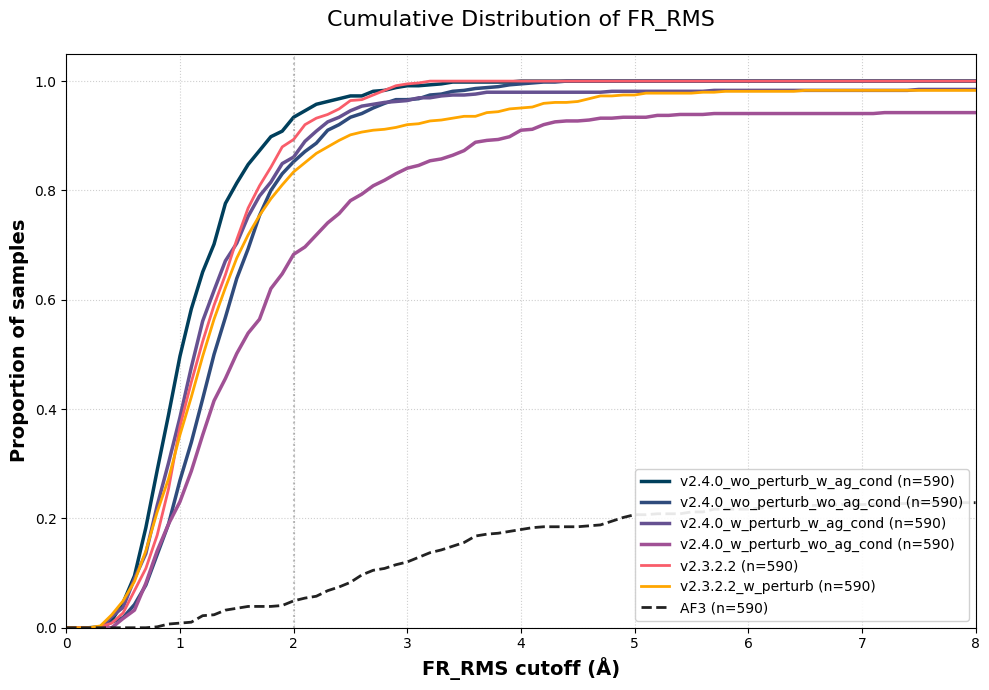

In [21]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

def collect_h3_rmsd(base_dir: str, target: str, max_samples_per_pdb: int = None) -> np.ndarray:
    """
    base_dir/pdb_id/rmsd/sample_xxx.json 구조에서 RMSD를 수집합니다.
    
    Args:
        base_dir: 루트 디렉토리
        max_samples_per_pdb: 각 PDB당 수집할 최대 JSON 파일 개수. 
                             None일 경우 해당 폴더의 모든 파일을 읽습니다.
    """
    h3_rmsds: List[float] = []

    if not os.path.exists(base_dir):
        print(f"Warning: Directory not found: {base_dir}")
        return np.array([])

    for pdb in os.listdir(base_dir):
        if 'config' in pdb or pdb.startswith('.'):
            continue

        rmsd_dir = os.path.join(base_dir, pdb, "rmsd")
        if not os.path.isdir(rmsd_dir):
            continue

        # 현재 PDB 폴더에서 수집한 샘플 카운트
        samples_collected = 0
        
        # 파일 목록을 정렬하여 읽거나 무작위성을 원하면 shuffle 가능
        json_files = [f for f in os.listdir(rmsd_dir) if f.endswith(".json")]
        
        for json_file in json_files:
            # 지정된 개수를 다 채웠으면 해당 PDB 폴더 종료
            if max_samples_per_pdb is not None and samples_collected >= max_samples_per_pdb:
                break

            json_path = os.path.join(rmsd_dir, json_file)
            
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
                
                val = data.get(target)
                if val is not None:
                    h3_rmsds.append(float(val))
                    samples_collected += 1 # 성공적으로 읽었을 때만 카운트 증가
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
                continue

    return np.asarray(h3_rmsds)
   

def compute_cdf(values: np.ndarray, cutoffs: np.ndarray) -> np.ndarray:
    if len(values) == 0:
        return np.zeros_like(cutoffs)
    # 각 cutoff보다 작거나 같은 값의 비율 계산
    return np.array([(values <= c).mean() for c in cutoffs])

def plot_cdfs(
    rmsd_dict: Dict[str, np.ndarray],
    target: str,
    cutoff_max: float = 8.0,
    step: float = 0.1,
):
    # 명확한 구분을 위한 커스텀 색상 매핑
    color_map = {
        # v2.4.0 시리즈 (차가운 계열로 변화를 줌)
        "v2.4.0_wo_perturb_w_ag_cond": "#003f5c",   # 진한 남색 (가장 좋은 조건 기대)
        "v2.4.0_wo_perturb_wo_ag_cond": "#2f4b7c",  # 중간 파랑
        "v2.4.0_w_perturb_w_ag_cond": "#665191",    # 보라색 느낌의 파랑
        "v2.4.0_w_perturb_wo_ag_cond": "#a05195",   # 자주색
        
        # v2.3.2.2 시리즈 (따뜻한 계열)
        "v2.3.2.2": "#f95d6a",                     # 분홍빛 빨강
        "v2.3.2.2_w_perturb": "#ffa600",           # 오렌지
        
        # 기준점
        "AF3": "#222222"                           # 거의 검은색
    }

    cutoffs = np.arange(0, cutoff_max + step, step)
    plt.figure(figsize=(10, 7)) # 가독성을 위해 크기 약간 확대

    for label, values in rmsd_dict.items():
        if len(values) == 0:
            continue
            
        cdf = compute_cdf(values, cutoffs)
        
        # 지정된 색상이 없으면 기본값(grey) 사용
        color = color_map.get(label, "#888888")
        
        # AF3는 점선(dashed)으로 표현하여 기준점임을 명시하거나, 
        # 굵기를 조절하여 가독성을 높입니다.
        linestyle = '--' if label == "AF3" else '-'
        linewidth = 2.5 if "v2.4.0" in label else 2.0
        
        plt.plot(cutoffs, cdf, label=f"{label} (n={len(values)})", 
                 color=color, linewidth=linewidth, linestyle=linestyle)

    plt.xlabel(f'{target.upper()} cutoff (Å)', fontsize=14, fontweight='bold')
    plt.ylabel('Proportion of samples', fontsize=14, fontweight='bold')
    plt.title(f'Cumulative Distribution of {target.upper()}', fontsize=16, pad=20)
    plt.legend(fontsize=10, loc='lower right', framealpha=0.9)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(0, cutoff_max)
    plt.ylim(0, 1.05)
    
    # 2A 혹은 4A 지점에 가이드라인 추가 (선택 사항)
    plt.axvline(x=2.0, color='grey', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# 실험 경로 설정 (필요시 경로 재확인)
experiment_dirs = {
    "v2.4.0_wo_perturb_w_ag_cond": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.4.0_loop_ppi/2026-01-29_00-29-37/epoch=57-step=41470/benchmark_wo_perturb_w_ag_cond",
    "v2.4.0_wo_perturb_wo_ag_cond": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.4.0_loop_ppi/2026-01-29_00-29-37/epoch=57-step=41470/benchmark_wo_perturb_wo_ag_cond",
    "v2.4.0_w_perturb_w_ag_cond": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.4.0_loop_ppi/2026-01-29_00-29-37/epoch=57-step=41470/benchmark_w_perturb_w_ag_cond",
    "v2.4.0_w_perturb_wo_ag_cond": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.4.0_loop_ppi/2026-01-29_00-29-37/epoch=57-step=41470/benchmark_w_perturb_wo_ag_cond",
    "v2.3.2.2": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/benchmark",
    "v2.3.2.2_w_perturb": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/benchmark_w_perturb",
    "AF3": "/home/psh/af3_output_filtered"
}
target = "fr_rms"
rmsd_results = {
    label: collect_h3_rmsd(path, target, max_samples_per_pdb=10)
    for label, path in experiment_dirs.items()
}

plot_cdfs(rmsd_results, target, cutoff_max=8.0, step=0.1)

In [25]:
def inspect_af3_keys(base_dir, n=5):
    for pdb in os.listdir(base_dir):
        rmsd_dir = os.path.join(base_dir, pdb, "rmsd")
        if not os.path.isdir(rmsd_dir):
            continue
        for f in os.listdir(rmsd_dir):
            if f.endswith(".json"):
                with open(os.path.join(rmsd_dir, f)) as fp:
                    data = json.load(fp)
                if "h3_rms" not in data.keys():
                    print(pdb)
                if data['h3_rms'] == None:
                    print(pdb)
            
base_dir = "/home/psh/af3_output_filtered"
inspect_af3_keys(base_dir)

7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij_H_L_CD
7uij

In [26]:
import os
import warnings
from tqdm import tqdm
from Bio.PDB import PDBParser, PDBIO
from Bio.SeqUtils import seq1
from abnum import Chain  # abnum 라이브러리 필요

def is_chothia_numbered(pdb_file):
    """
    PDB 파일이 Chothia numbering으로 되어 있는지 검증.
    H-chain의 특정 위치(예: H100) 이후에 Insertion code(A, B, C...)가 
    발견되거나, abnum의 결과와 일치하는지 간단히 체크합니다.
    """
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure("_", pdb_file)
        # 첫 번째 체인(보통 Heavy chain)의 잔기 ID들을 확인
        chain = next(structure.get_chains())
        res_ids = [res.id[1] for res in chain.get_residues()]
        
        # 간단한 검증: 번호가 1, 2, 3... 순서대로만 되어 있고 
        # 항체 길이가 100이 넘는데도 특정 영역 번호 건너뜀이나 icode가 전혀 없다면 
        # renumbering이 안 된 것으로 간주할 수 있습니다.
        # 여기서는 더 확실하게 하기 위해 리턴 False 후 renumbering 함수 내부에서 대조합니다.
        return False 
    except:
        return False

def renumber_pdb_wt_constant(in_pdb_file, out_pdb_file=None, scheme="chothia"):
    """
    제공해주신 renumber_pdb 로직을 바탕으로 한 항체 번호 재할당 함수
    """
    if out_pdb_file is None:
        out_pdb_file = in_pdb_file

    parser = PDBParser(QUIET=True)
    with warnings.catch_warnings(record=True):
        structure = parser.get_structure("_", in_pdb_file)

    changed = False
    for i, chain in enumerate(structure.get_chains()):
        if i >= 2: break  # H, L 체인만 처리
        
        # 현재 서열 추출
        res_list = list(chain.get_residues())
        seq = seq1(''.join([res.resname for res in res_list]))
        
        try:
            abnum_chain = Chain(seq, scheme=scheme)
            numbering = list(abnum_chain.positions.items())
        except Exception as e:
            print(f"Abnum error on {in_pdb_file}, chain {chain.id}: {e}")
            return False

        if len(res_list) != len(numbering):
            continue

        for pdb_r, (pos, aa) in zip(res_list, numbering):
            # pos 예: ('H', (100, ' ')) 또는 'H100 ' 등 라이브러리 출력 형태에 맞춰 가공
            # abnum의 pos 객체에서 숫자와 icode 추출
            new_resseq = pos.number
            new_icode = pos.letter if pos.letter else ' '
            
            old_id = pdb_r.id
            new_id = (' ', new_resseq, new_icode)
            
            if old_id != new_id:
                pdb_r.id = new_id
                changed = True

    if changed:
        io = PDBIO()
        io.set_structure(structure)
        io.save(out_pdb_file)
        return True
    return False

def process_all_af3_outputs(base_dir):
    pdb_folders = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    
    for pdb_id in tqdm(pdb_folders, desc="Processing PDB folders"):
        pdb_path = os.path.join(base_dir, pdb_id)
        
        for file_name in os.listdir(pdb_path):
            if file_name.endswith(".pdb") and not any(x in file_name for x in ["plddt", "trans"]):
                full_path = os.path.join(pdb_path, file_name)
                
                # 검증 및 적용
                # 로직: 일단 실행하고, 내부에서 'changed'가 발생했을 때만 저장함
                success = renumber_pdb_wt_constant(full_path)
                
                if success:
                   print(f"Renumbered: {full_path}")

if __name__ == "__main__":
    target_dir = "/home/psh/af3_output_filtered"
    process_all_af3_outputs(target_dir)

ModuleNotFoundError: No module named 'abnum'

## plddt scatter plot

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 데이터 로드 및 전처리
# -------------------------------
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-12_17-05-26/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'
plddt_data = pd.read_csv(csv_file)

# 평균 컬럼 추가
plddt_data['h_avg'] = plddt_data[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)

# mt_id별 최고값만 선택
best_rows = plddt_data.loc[plddt_data.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numeric_list(mt_id):
    parts = mt_id.split('_')
    nums = []
    if mt_id == pdb_id:
        return nums
    for p in parts:
        if 'A' in p:
            nums.append(int(p.replace('A', '')))
    return nums

best_rows['num_list'] = best_rows['mt_id'].apply(extract_numeric_list)

def count_in_range(nums, start, end):
    return sum(start <= n <= end for n in nums)

best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: count_in_range(x, 25, 32))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: count_in_range(x, 51, 57))

# (h1_count, h2_count) 조합 문자열
best_rows['count_pair'] = best_rows.apply(lambda x: f"({x.h1_count}, {x.h2_count})", axis=1)

# (0,0) 제외
zero_df = best_rows[(best_rows['h1_count'] == 0) & (best_rows['h2_count'] == 0)]
plot_df = best_rows[~((best_rows['h1_count'] == 0) & (best_rows['h2_count'] == 0))].copy()

# -------------------------------
# long-format 변환 (h1/h2 구분)
# -------------------------------
melt_df = pd.melt(
    plot_df,
    id_vars=['count_pair'],
    value_vars=['h1_plddt', 'h2_plddt'],
    var_name='cdr',
    value_name='plddt'
)

# -------------------------------
# x축 정렬 순서 계산 (튜플 오름차순)
# -------------------------------
# 문자열 "(a, b)" → (a, b) 정수 튜플로 변환
def parse_pair(s):
    return tuple(map(int, s.strip('()').split(', ')))

unique_pairs = sorted(melt_df['count_pair'].unique(), key=parse_pair)
print("✅ 정렬 순서:", unique_pairs)

# violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=melt_df,
    x='count_pair',
    y='plddt',
    hue='cdr',
    order=unique_pairs,    # ✅ 오름차순 순서 적용
    split=False,
    inner='quartile',
    linewidth=1,
    palette={'h1_plddt': 'skyblue', 'h2_plddt': 'lightcoral'}
)

# -------------------------------
# (0,0) 평균선 표시
# -------------------------------
if not zero_df.empty:
    plt.axhline(zero_df['h1_plddt'].mean(), color='blue', linestyle='--', label='WT h1 plddt')
    plt.axhline(zero_df['h2_plddt'].mean(), color='red', linestyle='--', label='WT h2 plddt')

plt.xlabel('(# of h1 insertion, # of h2 insertion)', fontsize=12)
plt.ylabel('pLDDT', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='CDR type')
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

## affinity scatter plot 

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
true_csv = "/home/psh/data/affinity/train/meta_2/metadata_train.csv"
pred_root = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_affinity_overfitting_5_lr_5e-4/2025-11-26_15-59-20/last/run_2025-11-26_16-45-07"

# Load true affinity
df_true = pd.read_csv(true_csv)
df_true = df_true[["pdb_name", "affinity"]]

pred_records = []

# Collect predicted affinity
for pdb_id in os.listdir(pred_root):
    json_path = os.path.join(pred_root, pdb_id, "sample_0", "affinity.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            data = json.load(f)
        pred = data.get("affinity_nm", None)
        if pred is not None:
            pred_records.append({"pdb_name": pdb_id, "pred_affinity": pred})

df_pred = pd.DataFrame(pred_records)

# Merge true & predicted
df = df_true.merge(df_pred, on="pdb_name", how="inner")

# pred_affinity 리스트 → float 변환

df["pred_affinity"] = df["pred_affinity"].apply(
    lambda x: x[0][0] if isinstance(x, list) else x
)

# log10 transform
df["log_true"] = np.log10(df["affinity"])
df["log_pred"] = np.log10(df["pred_affinity"])

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(df["log_true"], df["log_pred"])
plt.xlabel("log10(True affinity)")
plt.ylabel("log10(Predicted affinity)")
plt.grid(True)
plt.show()


## pairformer 비교 및 시각화 

In [ ]:
import torch
import matplotlib.pyplot as plt
from Bio import PDB
import re 

# --------------------------
# 1. Load tensors
# --------------------------
file_1 = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5ggs_optimab/5ggs_H_L_A_A24G_S25T_T28I_T30S_Y32T_M34I__S54L__Y101K_R102N_Y109L/pair.pt"
file_2 = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5ggs_dms/5ggs_H_L_A_WT__WT__WT/pair.pt"
mt_1 = torch.load(file_1, map_location='cpu')
mt_2 = torch.load(file_2, map_location='cpu')

pure_mt_1 = file_1.split('/')[-2].replace("5ggs_H_L_A_", "")
pure_mt_2 = file_2.split('/')[-2].replace("5ggs_H_L_A_", "")

# --------------------------
# 2. Compute absolute mean difference
# --------------------------
tensor_2d = (mt_1['z'] - mt_2['z']).abs().mean(dim=-1)  # shape [L, L]
L = tensor_2d.shape[0]

# --------------------------
# 3. Load loop mask (no PDB mapping)
# --------------------------
loop_mask_1 = mt_1['loop_mask']  # [L]
loop_mask_2 = mt_2['loop_mask']  # [L]

print(loop_mask_1)

# CDR index list
cdr_indices = (loop_mask_1 == 1).nonzero(as_tuple=True)[0].tolist()

print("CDR index list:", cdr_indices)

# --------------------------
# Visualization
# --------------------------
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(tensor_2d.cpu().numpy(), aspect='equal', vmin=0.0, vmax=4.0)
plt.colorbar(im, ax=ax)
ax.set_title(f"|{pure_mt_1} - {pure_mt_2}|")

146
plt.tight_layout()
plt.show()

In [31]:
from data.utils import read_pkl, INT_TO_CHAIN, CHAIN_TO_INT

chain_info = read_pkl("/home/psh/BioBetter/kkh_output/meta/8tg9_E_F_B/41th_sample_0.pkl")
chain_index = list(set(chain_info['chain_index']))


for ci in chain_index:
    print(INT_TO_CHAIN[ci])

A
B
C


## plddt 기반으로 가장 좋은 pdb 샘플링하기 

In [ ]:
import os 
import json 

input_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/run_2025-12-22_14-15-11/fold_gkr_01l_ec24_ca_3_model_0'
plddts = {}
metrics = ['h3']

# 1. 파일 읽기 및 점수 저장
for file in os.listdir(input_dir):
    if 'plddt' not in file:
        continue 

    plddt_path = os.path.join(input_dir, file)
    try:
        with open(plddt_path, 'r') as f:
            data = json.load(f)
        
        temp_b_factor = 0
        for metric in metrics:
            # 해당 metric 키가 없을 경우를 대비해 get 사용 권장 (기본값 0)
            temp_b_factor += data.get(f'{metric}_aa', 0)

        plddts[file] = temp_b_factor
    except Exception as e:
        print(f"Error parsing {file}: {e}")

# 2. 정렬 및 Top 5 추출
# plddts.items()는 (key, value) 튜플을 반환합니다.
# key=lambda item: item[1] 은 value(점수)를 기준으로 정렬하겠다는 의미입니다.
sorted_plddts = sorted(plddts.items(), key=lambda item: item[1], reverse=True)

top_5_files = sorted_plddts[:5]

# 3. 결과 출력
print(f"=== Top 5 Files (Metric: {metrics}) ===")
for rank, (filename, score) in enumerate(top_5_files, 1):
    print(f"Rank {rank}: {filename} | Score: {score:.4f}")

# 필요하다면 파일명 리스트만 따로 저장
top_5_filenames = [item[0] for item in top_5_files]
# print(top_5_filenames)

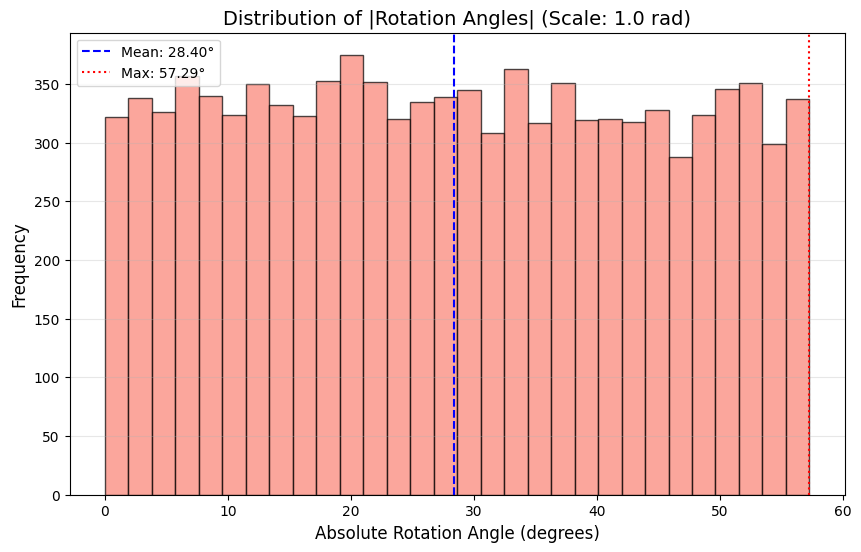

In [37]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_absolute_rotation_angles(batch_size=10000, rotation_scale=1.5):
    # 1. 원본 로직대로 난수 생성
    rand_angle_rad = (torch.rand(batch_size, 1) * 2 - 1) * rotation_scale
    
    # 2. 절댓값 취하기
    abs_angle_rad = torch.abs(rand_angle_rad)
    
    # 3. 도(degree) 단위로 변환
    abs_angle_deg = abs_angle_rad * (180.0 / np.pi)
    
    # 4. 시각화
    plt.figure(figsize=(10, 6))
    plt.hist(abs_angle_deg.numpy(), bins=30, color='salmon', edgecolor='black', alpha=0.7)
    
    # 통계치
    mean_abs = abs_angle_deg.mean().item()
    max_abs = abs_angle_deg.max().item()
    
    plt.title(f'Distribution of |Rotation Angles| (Scale: {rotation_scale} rad)', fontsize=14)
    plt.xlabel('Absolute Rotation Angle (degrees)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    # 평균 및 최대값 표시
    plt.axvline(mean_abs, color='blue', linestyle='dashed', label=f'Mean: {mean_abs:.2f}°')
    plt.axvline(max_abs, color='red', linestyle='dotted', label=f'Max: {max_abs:.2f}°')
    
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.show()

visualize_absolute_rotation_angles(rotation_scale=1.0)

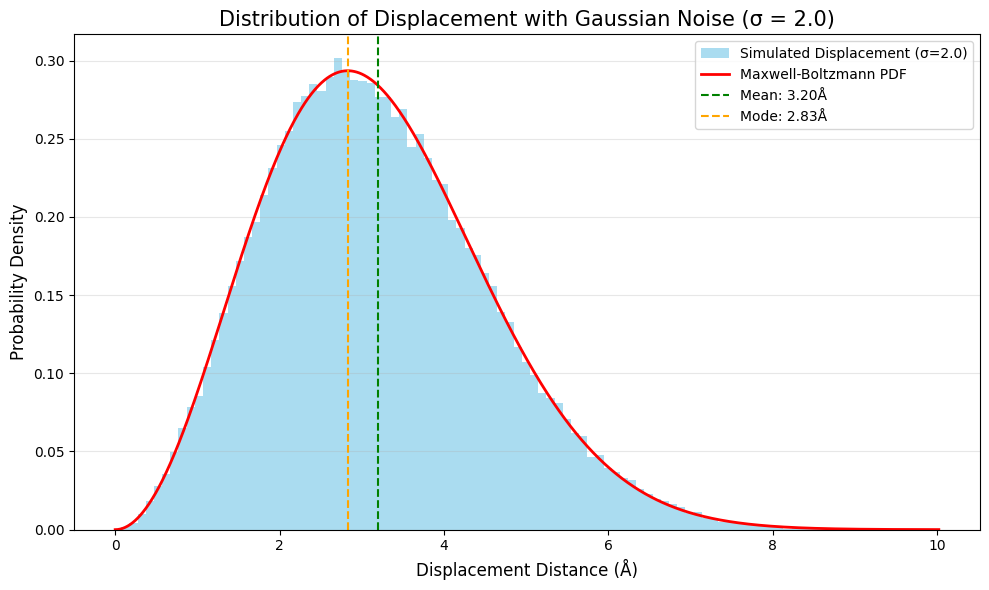

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import maxwell

def visualize_noise_displacement(sigma=6.0, num_samples=100000):
    # 1. 3차원 가우시안 노이즈 생성 (x, y, z 각각 sigma=7.0)
    noise = np.random.normal(0, sigma, size=(num_samples, 3))
    
    # 2. 이동 거리 계산 (Euclidean distance)
    distances = np.linalg.norm(noise, axis=1)
    
    # 3. 이론적인 확률 밀도 함수(PDF) 계산
    # scipy의 maxwell은 scale 파라미터로 sigma를 사용함
    x_phi = np.linspace(0, distances.max(), 1000)
    pdf = maxwell.pdf(x_phi, scale=sigma)
    
    # 4. 시각화
    plt.figure(figsize=(10, 6))
    
    # 히스토그램
    plt.hist(distances, bins=100, density=True, color='skyblue', alpha=0.7, 
             label=f'Simulated Displacement (σ={sigma})')
    
    # 이론적 곡선
    plt.plot(x_phi, pdf, color='red', lw=2, label='Maxwell-Boltzmann PDF')
    
    # 통계량 표시
    mean_dist = np.mean(distances)
    mode_dist = x_phi[np.argmax(pdf)]
    
    plt.axvline(mean_dist, color='green', linestyle='--', label=f'Mean: {mean_dist:.2f}Å')
    plt.axvline(mode_dist, color='orange', linestyle='--', label=f'Mode: {mode_dist:.2f}Å')

    plt.title(f'Distribution of Displacement with Gaussian Noise (σ = {sigma})', fontsize=15)
    plt.xlabel('Displacement Distance (Å)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_noise_displacement(sigma=2.0)

## Dockq result 

Detected columns - Capri: dockq, Raw: dockq_score
Merged DataFrame shape: (420, 4)


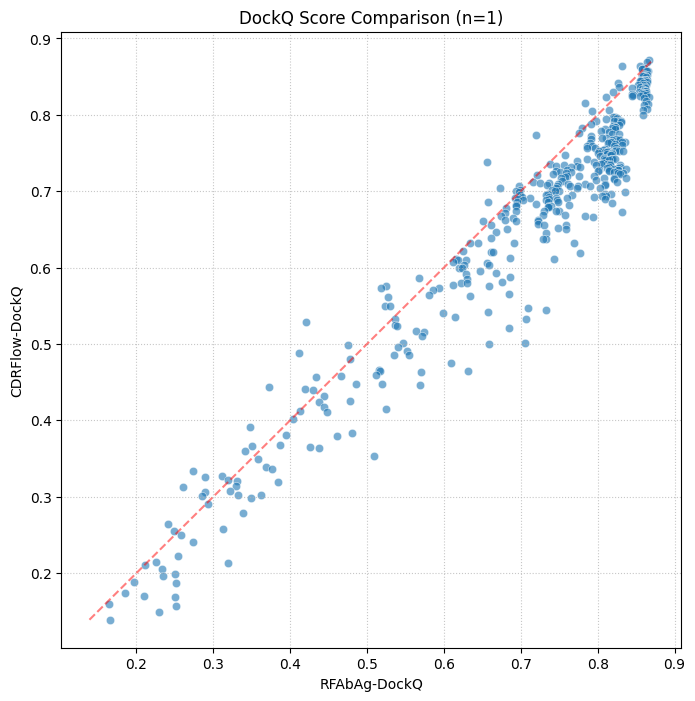

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 불러오기
capri_path = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.4.0_loop_ppi/2026-01-29_00-29-37/epoch=57-step=41470/kkh_w_ag_cond/get_capri/capri_info.csv'
raw_path = '/home/psh/BioBetter/kkh_output/meta/raw_results.csv'

df_capri = pd.read_csv(capri_path)
df_raw = pd.read_csv(raw_path)

# 2. capri_info 전처리 (ID 분리)
def split_name(name):
    parts = str(name).split('_')
    pdb_id = "_".join(parts[:4])
    data_name = "_".join(parts[4:])
    return pd.Series([pdb_id, data_name])

df_capri[['pdb_id', 'data_name']] = df_capri['name'].apply(split_name)

# 3. 'dockq' 포함 컬럼 식별 (에러 방지를 위해 직접 지정하거나 자동 탐색)
# 만약 확실히 안다면 직접 문자열로 넣으셔도 됩니다 (예: 'dockq_score')
capri_dockq_col = [c for c in df_capri.columns if 'dockq' in c.lower()][0]
raw_dockq_col = [c for c in df_raw.columns if 'dockq' in c.lower()][0]

print(f"Detected columns - Capri: {capri_dockq_col}, Raw: {raw_dockq_col}")

# 4. n번째 큰 값 추출 (예: 1번째)
n = 1
df_capri_grouped = df_capri.sort_values(by=capri_dockq_col, ascending=False) \
                           .groupby('name') \
                           .nth(n-1).reset_index()

# 5. 데이터 병합 (Merge)
merged_df = pd.merge(
    df_capri_grouped[['pdb_id', 'data_name', capri_dockq_col]],
    df_raw[['pdb_id', 'data_name', raw_dockq_col]],
    on=['pdb_id', 'data_name'],
    suffixes=('_capri', '_raw')
)

# --- 검증 단계 ---
print(f"Merged DataFrame shape: {merged_df.shape}")
if merged_df.empty:
    print("❌ 매칭된 데이터가 없습니다! pdb_id나 data_name 형식을 확인하세요.")
    print(f"Capri sample ID: {df_capri['pdb_id'].iloc[0]}, Data: {df_capri['data_name'].iloc[0]}")
    print(f"Raw sample ID: {df_raw['pdb_id'].iloc[0]}, Data: {df_raw['data_name'].iloc[0]}")
else:
    # 컬럼명이 중복되지 않아 suffix가 안 붙었을 경우를 대비해 실제 컬럼명 재확인
    final_x = f"{raw_dockq_col}_raw" if f"{raw_dockq_col}_raw" in merged_df.columns else raw_dockq_col
    final_y = f"{capri_dockq_col}_capri" if f"{capri_dockq_col}_capri" in merged_df.columns else capri_dockq_col

    # 6. Scatter Plot
    plt.figure(figsize=(8, 8))
    plt.xlabel("RFAbAg-DockQ")
    plt.ylabel("CDRFlow-DockQ")
    sns.scatterplot(data=merged_df, x=final_x, y=final_y, alpha=0.6)

    # 대각선
    all_vals = pd.concat([merged_df[final_x], merged_df[final_y]])
    line_range = [all_vals.min(), all_vals.max()]
    plt.plot(line_range, line_range, color='red', linestyle='--', alpha=0.5)

    plt.title(f'DockQ Score Comparison (n={n})')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

In [6]:
# 7. x - y 차이 계산
merged_df["diff_xy"] = merged_df[final_x] - merged_df[final_y]

# x축 값이 y축 값보다 큰 경우 (x > y) → diff가 큰 순
top5_x_bigger = (
    merged_df[merged_df["diff_xy"] > 0]
    .sort_values("diff_xy", ascending=False)
    .head(5)
)

# y축 값이 x축 값보다 큰 경우 (y > x) → (y-x)가 큰 순
top5_y_bigger = (
    merged_df[merged_df["diff_xy"] < 0]
    .assign(diff_yx=lambda x: -x["diff_xy"])
    .sort_values("diff_yx", ascending=False)
    .head(5)
)

print("\n===== Top 5 : x(RFAbAg-DockQ) > y(CDRFlow-DockQ) =====")
print(
    top5_x_bigger[
        ["pdb_id", "data_name", final_x, final_y, "diff_xy"]
    ]
)

print("\n===== Top 5 : y(CDRFlow-DockQ) > x(RFAbAg-DockQ) =====")
print(
    top5_y_bigger[
        ["pdb_id", "data_name", final_x, final_y, "diff_yx"]
    ]
)



===== Top 5 : x(RFAbAg-DockQ) > y(CDRFlow-DockQ) =====
         pdb_id      data_name  dockq_score     dockq   diff_xy
282  8vvl_H_L_A  20th_sample_0     0.831346  0.578102  0.253244
309  8aci_H_L_A  50th_sample_0     0.747520  0.540142  0.207378
285  8vvl_H_L_A  42th_sample_0     0.769300  0.575719  0.193581
269  8hs2_B_C_R  10th_sample_0     0.805795  0.619170  0.186625
283  8hs2_B_C_R   9th_sample_0     0.759364  0.577046  0.182317

===== Top 5 : y(CDRFlow-DockQ) > x(RFAbAg-DockQ) =====
          pdb_id      data_name  dockq_score     dockq   diff_yx
337   8jel_C_D_J  22th_sample_0     0.411922  0.487904  0.075981
1     8f5n_H_L_A  19th_sample_0     0.776290  0.849223  0.072934
144   7yru_H_L_A  31th_sample_0     0.656016  0.727529  0.071513
2     8f5n_H_L_A  20th_sample_0     0.783922  0.848802  0.064880
316  8b7h_H_L_AB  25th_sample_0     0.477323  0.529123  0.051800


## dockq score 비교 

dockq columns: dockq dockq
matched pdb count: 29


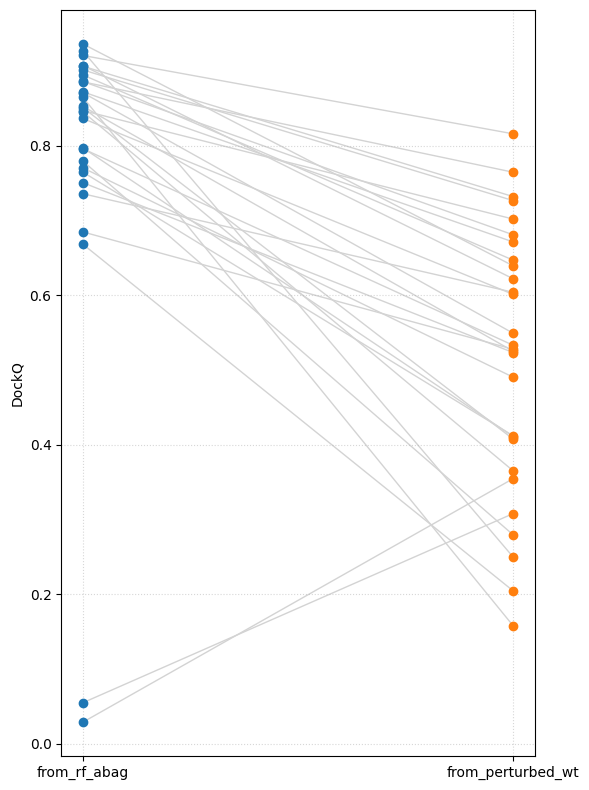

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

capri1_path = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.4.0_loop_ppi/2026-01-29_00-29-37/epoch=57-step=41470/run_2026-01-31_00-25-08/get_capri/capri_info.csv"

capri2_path = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.4.0_loop_ppi/2026-01-29_00-29-37/epoch=57-step=41470/kkh_w_ag_cond/get_capri/capri_info.csv"


df1 = pd.read_csv(capri1_path)
df2 = pd.read_csv(capri2_path)

# dockq 컬럼 자동 탐색
dockq1_col = [c for c in df1.columns if "dockq" in c.lower()][0]
dockq2_col = [c for c in df2.columns if "dockq" in c.lower()][0]

print("dockq columns:", dockq1_col, dockq2_col)

# -----------------------------
# 두 번째 csv
# name split → pdb_id
# -----------------------------
df2["pdb_id"] = df2["name"].astype(str).str.split("_").str[0]

df2_mean = (
    df2
    .groupby("pdb_id")[dockq2_col]
    .mean()
    .reset_index()
    .rename(columns={dockq2_col: "from_perturbed_wt"})
)

# -----------------------------
# 첫 번째 csv
# name에 pdb_id가 포함된 행의 dockq
# -----------------------------
rows = []

for pdb_id in df2_mean["pdb_id"].unique():
    sub = df1[df1["name"].astype(str).str.contains(pdb_id)]

    if len(sub) == 0:
        continue

    # 여러 개면 평균으로 (안전하게)
    rows.append({
        "pdb_id": pdb_id,
        "from_rf_abag": sub[dockq1_col].mean()
    })

df1_selected = pd.DataFrame(rows)

# -----------------------------
# merge
# -----------------------------
merged = pd.merge(
    df1_selected,
    df2_mean,
    on="pdb_id",
    how="inner"
)

print("matched pdb count:", len(merged))

# -----------------------------
# plot
# -----------------------------
x_labels = ["from_rf_abag", "from_perturbed_wt"]
x_pos = [0, 1]

left_color = "tab:blue"
right_color = "tab:orange"
line_color = "lightgray"

plt.figure(figsize=(6, 8))

for _, row in merged.iterrows():
    y0 = row["from_rf_abag"]
    y1 = row["from_perturbed_wt"]

    # 연결선 (회색)
    plt.plot(
        x_pos,
        [y0, y1],
        color=line_color,
        linewidth=1,
        zorder=1
    )

    # 좌변 점
    plt.scatter(
        0, y0,
        color=left_color,
        zorder=2
    )

    # 우변 점
    plt.scatter(
        1, y1,
        color=right_color,
        zorder=2
    )

plt.xticks(x_pos, x_labels)
plt.ylabel("DockQ")

plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()
